<a href="https://colab.research.google.com/github/mkolennikova/TEB-Ru/blob/main/run_in_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Basic imports

In [1]:
import os, sys, shutil, glob, time
import subprocess
import importlib
import pandas as pd
from pathlib import Path

def import_and_reload (module_name: str):
    """Loads a module by name, or reloads it if already imported."""
    if module_name in sys.modules:
        print(f"Reloading existing module: {module_name}")
        return importlib.reload(sys.modules[module_name])
    else:
        print(f"Loading new module: {module_name}")
        return importlib.import_module(module_name)


In [36]:
opts = {'use_gdrive': False,
        'reload_repo': False,
        'repo_path': 'https://github.com/mkolennikova/TEB-Ru'}

MODEL_NAME = os.path.basename(os.path.normpath(opts['repo_path']))

In [3]:
if opts['use_gdrive']:
  from google.colab import drive
  drive.mount('/content/drive')
  WORK_DIR = '/content/drive/MyDrive/TEB_work'
else:
  WORK_DIR = '/content/TEB_work'

MODEL_DIR = WORK_DIR + '/' + MODEL_NAME

os.makedirs(WORK_DIR, exist_ok = True)


## Update model from GitHub

```reload_repo = True```: clone model repository from remote, cleaning all local changes

```reload_repo = False```: update repository by calling ```git pull```

In [43]:
os.chdir (WORK_DIR)
if not os.path.isdir (MODEL_NAME) or opts['reload_repo']:
  if os.path.isdir (MODEL_NAME):
    %rm -r {MODEL_NAME}
  !git clone {opts['repo_path']}
else:
  os.chdir(MODEL_DIR)
  !git pull



remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 426 bytes | 426.00 KiB/s, done.
From https://github.com/mkolennikova/TEB-Ru
   6d7fecd..22d2fc0  main       -> origin/main
Updating 6d7fecd..22d2fc0
Fast-forward
 python/output_utils.py | 6 ++++--
 1 file changed, 4 insertions(+), 2 deletions(-)


In [14]:
sys.path.append (MODEL_DIR + '/python/')
install_utils = import_and_reload ('install_utils')

install_utils.import_extrernal_modules()


Reloading existing module: install_utils
'f90nml' exists.
'cdsapi' exists.


## Model compilation

In [15]:
run_utils = import_and_reload ('run_utils')

start_time = time.time()

for comand in ['all']:
  run_utils.run_in_cell(exe_path='make',
                        args=['-C', MODEL_DIR, comand],
                        num_lines = 10,
                        log_file=f'{MODEL_DIR}/make_{comand}_output.txt')

new_files = [f for f in glob.glob(MODEL_DIR + '/*.*') if os.path.getmtime(f) >= start_time]

print('\nCompilation finished, new files created:\n' + '\n'.join('\t' + f for f in new_files))

exe_files = [f for f in new_files if f.endswith('.exe')]
if exe_files:
  if len (exe_files) == 1:
    EXE_PATH = exe_files[0]
    EXE_FILE = os.path.basename(EXE_PATH)
    print (f'✅ Compilation is successfull, executable is {EXE_PATH}')
  else:
    print ('❌ Something is wrong: there is more than one new executable file')
else:
    print ('❌ Something is wrong: there are not any new executable file')


gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/init_surfconsphy.F -o obj/init_surfconsphy.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_driver/add_forecast_to_date_surf.F90 -o obj/add_forecast_to_date_surf.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/bld_occ_calendar.F90 -o obj/bld_occ_calendar.o
gfortran   -funderscoring -O0 -g -Wall -c -fmessage-length=0 -fdefault-real-8 -ffpe-trap=invalid,zero -ffree-line-length-0 -Wno-tabs -Wno-unused -Wno-align-commons -I. -Isrc_teb -Jobj -I. -Isrc_teb  -c src_teb/

## Test model run with default settings

In [16]:
run_utils = import_and_reload ('run_utils')
run_utils.run_in_cell(exe_path='./TEB_offline.exe', cwd = MODEL_DIR, log_file='TEB_log.txt', num_lines=5)

  
     --------------------------
     |  TEB-Ru OFFLINE SIMULATION ENDS CORRECTLY |
     --------------------------
  
✅ Process finished (return code 0). Full log saved to 'TEB_log.txt'.


0

## Download atmospheric forcing for your custom experiment

In [ ]:
install_utils.init_CDS()

Loading new module: forcing_ERA5
📥 Downloading ERA5 data for (55.030204, 82.92043) from 2024-01-01 to 2024-12-31...


2026-06-28 14:55:18,975 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
INFO:ecmwf.datastores.legacy_client:[2026-02-16T00:00:00] - To generate this ERA5 hourly time series datase

3bcc90d3b8681b72398364dd3dd5dbc9.zip:   0%|          | 0.00/441k [00:00<?, ?B/s]

✅ Extracted and saved to Novosibirsk/forcing_ERA5/forcing_nc/era5_2024-01-01_2024-12-31.nc
✅ Downloaded 1 file(s) to Novosibirsk/forcing_ERA5/forcing_nc
📊 Preparing forcing DataFrame...
DataFrame saved to Novosibirsk/forcing_ERA5/era5_forcing_2024-01-01_2024-12-31.csv
✅ DataFrame saved to Novosibirsk/forcing_ERA5/era5_forcing_2024-01-01_2024-12-31.csv
💾 Writing forcing text files...


Saving forcing variables: 100%|██████████| 11/11 [00:00<00:00, 41.88it/s]


✅ Forcing files written to Novosibirsk/forcing_ERA5/forcing_txt
📝 Writing namelist...
✅ Namelist saved to Novosibirsk/forcing_ERA5/namelist_forcing.nml
📈 Generating plot...
Auto-resampling to daily (number of points: 8784)
Plot saved to Novosibirsk/forcing_ERA5/era5_forcing_2024-01-01_2024-12-31.png


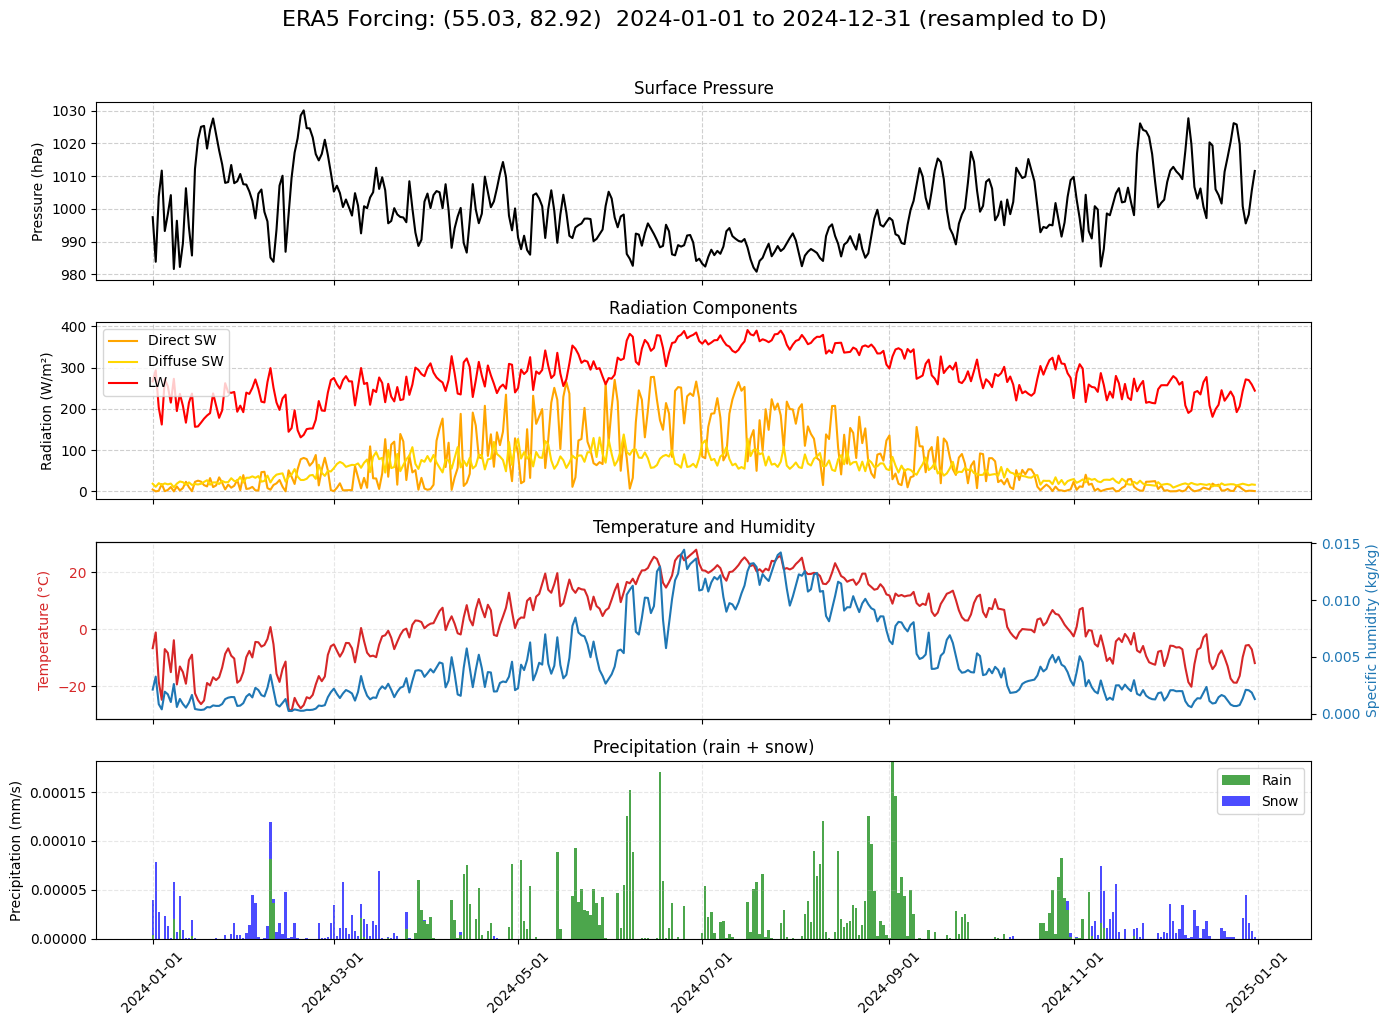

✅ Plot saved to Novosibirsk/forcing_ERA5/era5_forcing_2024-01-01_2024-12-31.png


In [20]:
forcing_ERA5 = import_and_reload ('forcing_ERA5')
os.chdir(WORK_DIR)

forcing_params = dict(lat = 55.030204,
                      lon = 82.920430,
                      base_dir = 'Novosibirsk',
                      start_date = '2024-01-01',
                      end_date = '2024-12-31',
                      time = '1h')


forcing_ERA5.prepare_forcing (**forcing_params)

## Configure your custom simulation based on downloaded forcing

In [33]:
import f90nml

site_name = 'Novosibirsk'
exp_name = 'CTRL'

FORCING_NML_PATH = f'{WORK_DIR}/{site_name}/forcing_ERA5/namelist_forcing.nml'
PARAMS_NML_PATH  = f'{WORK_DIR}/{site_name}/params_{exp_name}.nml'
OUTPUT_DIR       = f'{WORK_DIR}/{site_name}/output_{exp_name}/'

os.makedirs(OUTPUT_DIR, exist_ok = True)

params_nml = f90nml.read(f'{MODEL_DIR}/namelist/namelist.nml')
params_nml['tebparam']['teb_utc_hour'] = 7

# ***** Insert other namelist modifications here ****
# params_nml['tebparam']['...'] = ...

params_nml.write(PARAMS_NML_PATH, force=True)




## Run model for your custom simulation using comand-line arguments

```
# Custom forcing namelist
./TEB_offline.exe -forcing_nml my_forcing.nml

# Custom parameters namelist
./TEB_offline.exe -forcing_nml my_forcing.nml -param_nml my_params.nml -output my_results/

# Custom output folder
./TEB_offline.exe -output my_results/

# Help
./TEB_offline.exe -help

```

In [35]:
run_utils = import_and_reload ('run_utils')
run_utils.run_in_cell(exe_path='./TEB_offline.exe',
                      args = ['-forcing_nml', FORCING_NML_PATH,
                              '-param_nml', PARAMS_NML_PATH,
                              '-output', OUTPUT_DIR],
                      log_file=f'{OUTPUT_DIR}/model_output.log', cwd = MODEL_DIR, num_lines=5)

  
     --------------------------
     |  TEB-Ru OFFLINE SIMULATION ENDS CORRECTLY |
     --------------------------
  
✅ Process finished (return code 0). Full log saved to '/content/TEB_work/Novosibirsk/output_CTRL//model_output.log'.


0

In [73]:
import output_utils
output_utils = import_and_reload ('output_utils')

output_df = output_utils.read_output (OUTPUT_DIR, FORCING_NML_PATH)


Reloading existing module: output_utils
/content/TEB_work/Novosibirsk/output_CTRL/SOLAR_PROD.txt is empty, skipping


In [74]:
output_df.head()

,T_WALLB1,T_ROOF1,T_CANYON,P_CANYON,RN_TOWN,T_WALLA1,H_TOWN,T_ROAD1,HVAC_HEAT,HVAC_COOL,TI_BLD,LE_TOWN,Q_CANYON,U_CANYON
2024-01-01 00:00:00,260.314318,260.081832,261.469791,100254.525388,-29.304764,260.314318,99.640898,260.125161,101.605730,0.0,295.281266,28.239074,0.001262,1.735127
2024-01-01 01:00:00,261.975816,260.838369,261.702260,100276.610679,-30.531964,261.975816,103.350550,260.301206,110.548527,0.0,292.206822,19.730496,0.001223,1.566481
2024-01-01 02:00:00,262.640609,261.159444,261.897348,100309.728516,-36.213221,262.640609,112.189003,260.334070,113.305381,0.0,292.160325,14.468510,0.001205,1.440605
2024-01-01 03:00:00,263.138694,261.587713,261.973892,100341.872396,-24.394055,263.138694,123.941399,260.602519,114.795480,0.0,292.159170,11.133350,0.001182,1.308533
2024-01-01 04:00:00,263.853648,262.384092,262.493942,100311.932292,-4.533097,263.853648,126.744909,261.116432,113.785916,0.0,292.159111,8.808187,0.001211,1.086617


(<Figure size 1000x1800 with 5 Axes>,
 array([<Axes: title={'center': 'Temperatures'}, ylabel='Temperature (K)'>,
        <Axes: title={'center': 'Canyon Wind Speed'}, ylabel='Wind speed (m/s)'>,
        <Axes: title={'center': 'Turbulent Heat Fluxes'}, ylabel='Heat flux (W/m²)'>,
        <Axes: title={'center': 'Net Radiation'}, ylabel='Net radiation (W/m²)'>,
        <Axes: title={'center': 'HVAC Energy Consumption'}, xlabel='Time', ylabel='Energy (W/m²)'>],
       dtype=object))

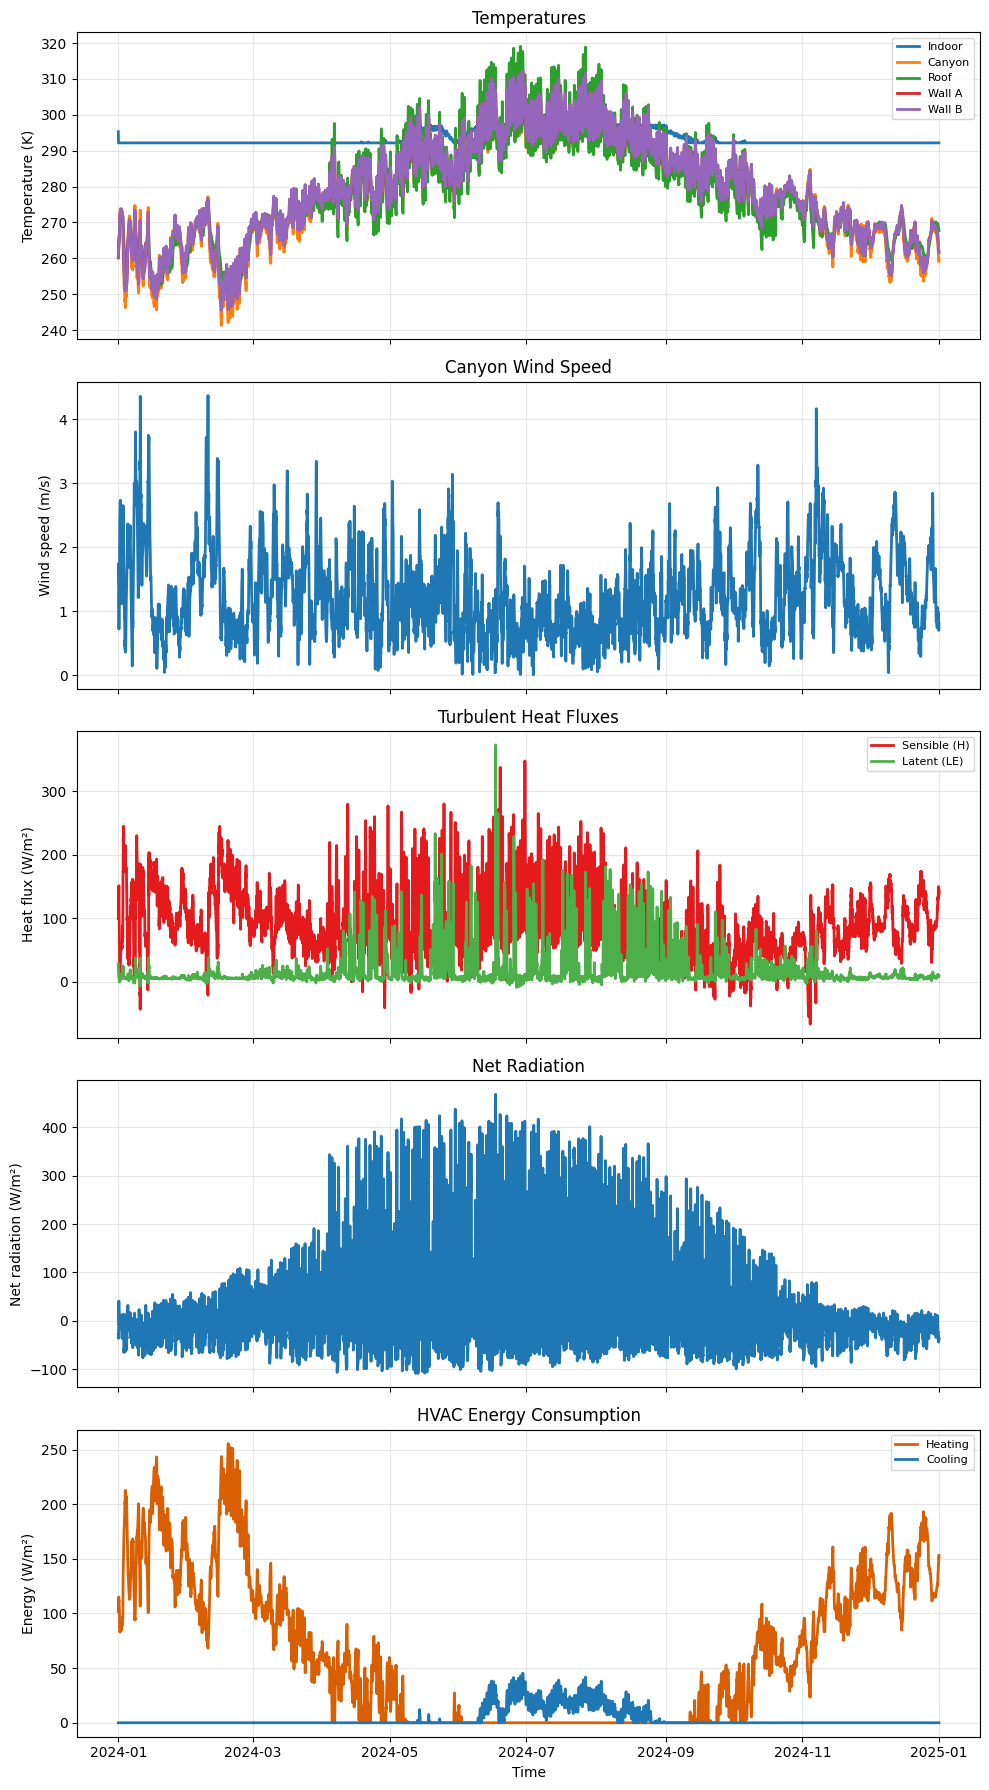

In [75]:
output_utils.plot_teb_simple (output_df)